# Daily Alpro Practice
### Question 1
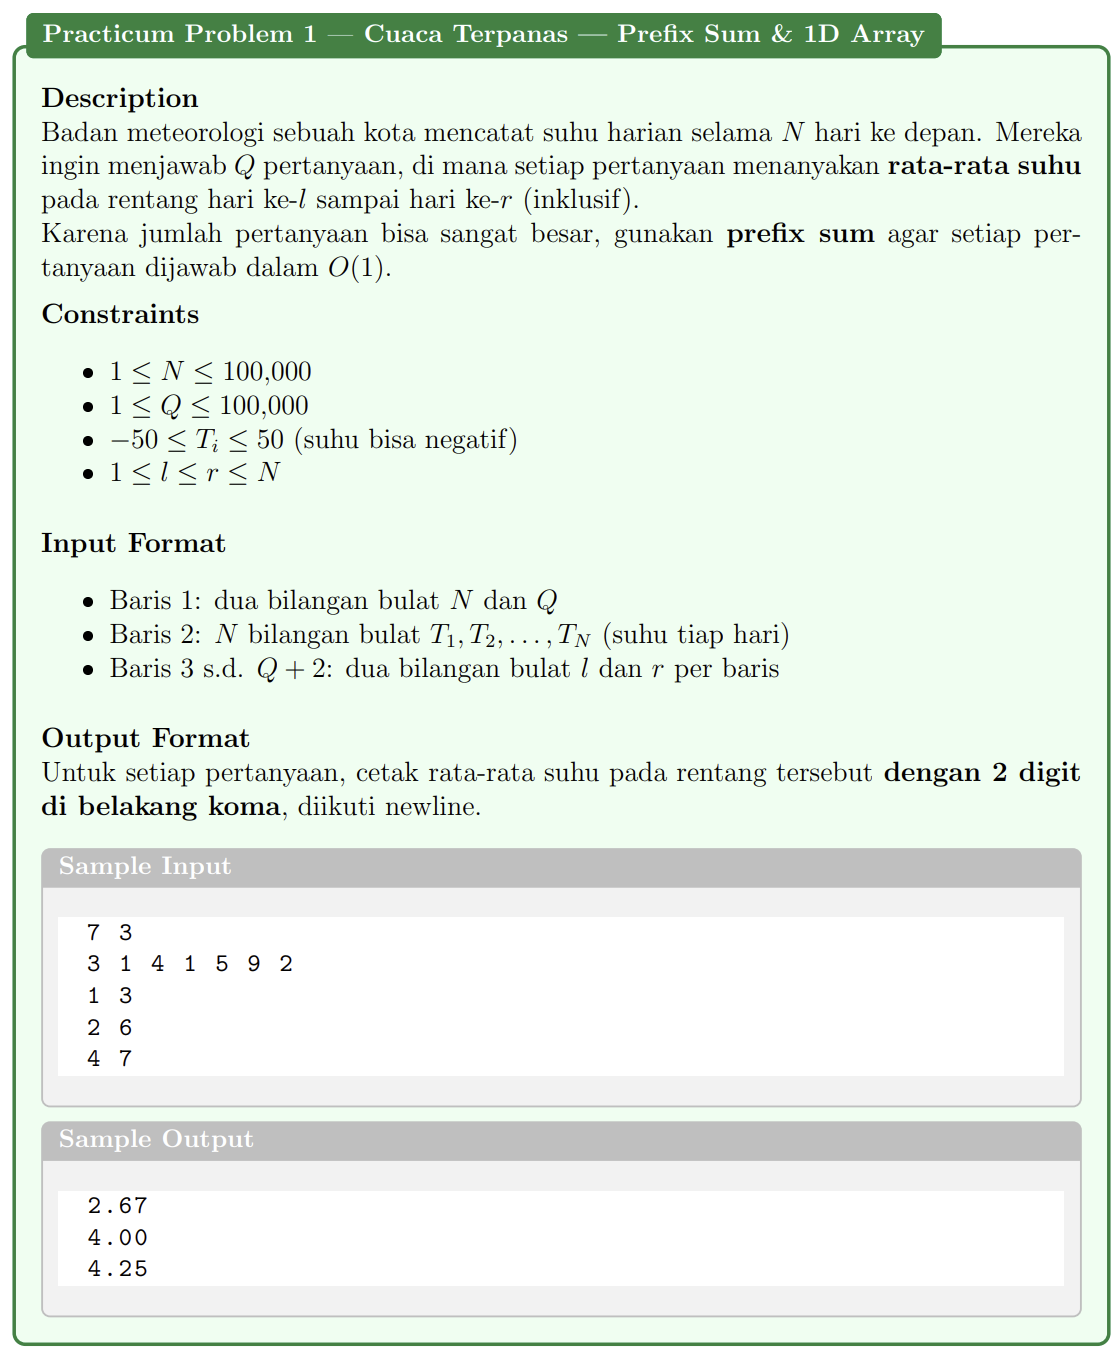

In [39]:
%%writefile daily210426_1.c
# include <stdio.h>

int main() {
  int jumlahHari = 0;
  int jumlahPertanyaan = 0;
  int suhu = 0;
  int left = 0;
  int right = 0;

  int sum = 0;
  float rataRata = 0;
  int PS[100000] = {0};

  scanf("%d %d", &jumlahHari, &jumlahPertanyaan);

  // Start from day 1 = index 1
  for (int i = 1; i <= jumlahHari; i++) {
    scanf("%d", &suhu);
    PS[i] = PS[i - 1] + suhu;
  }

  for (int i = 0; i < jumlahPertanyaan; i++) {
    scanf("%d %d", &left, &right);

    // PS[b] - PS[a-1]
    sum = PS[right] - PS[left - 1];
    rataRata = (sum * 1.0)/(right - left + 1);
    printf("%.2f\n", rataRata);
  }

  return 0;
}

Overwriting daily210426_1.c


In [40]:
!gcc daily210426_1.c -o daily210426_1 && echo 7 3 3 1 4 1 5 9 2 1 3 2 6 4 7 | daily210426_1.exe

2.67
4.00
4.25


### Question 2
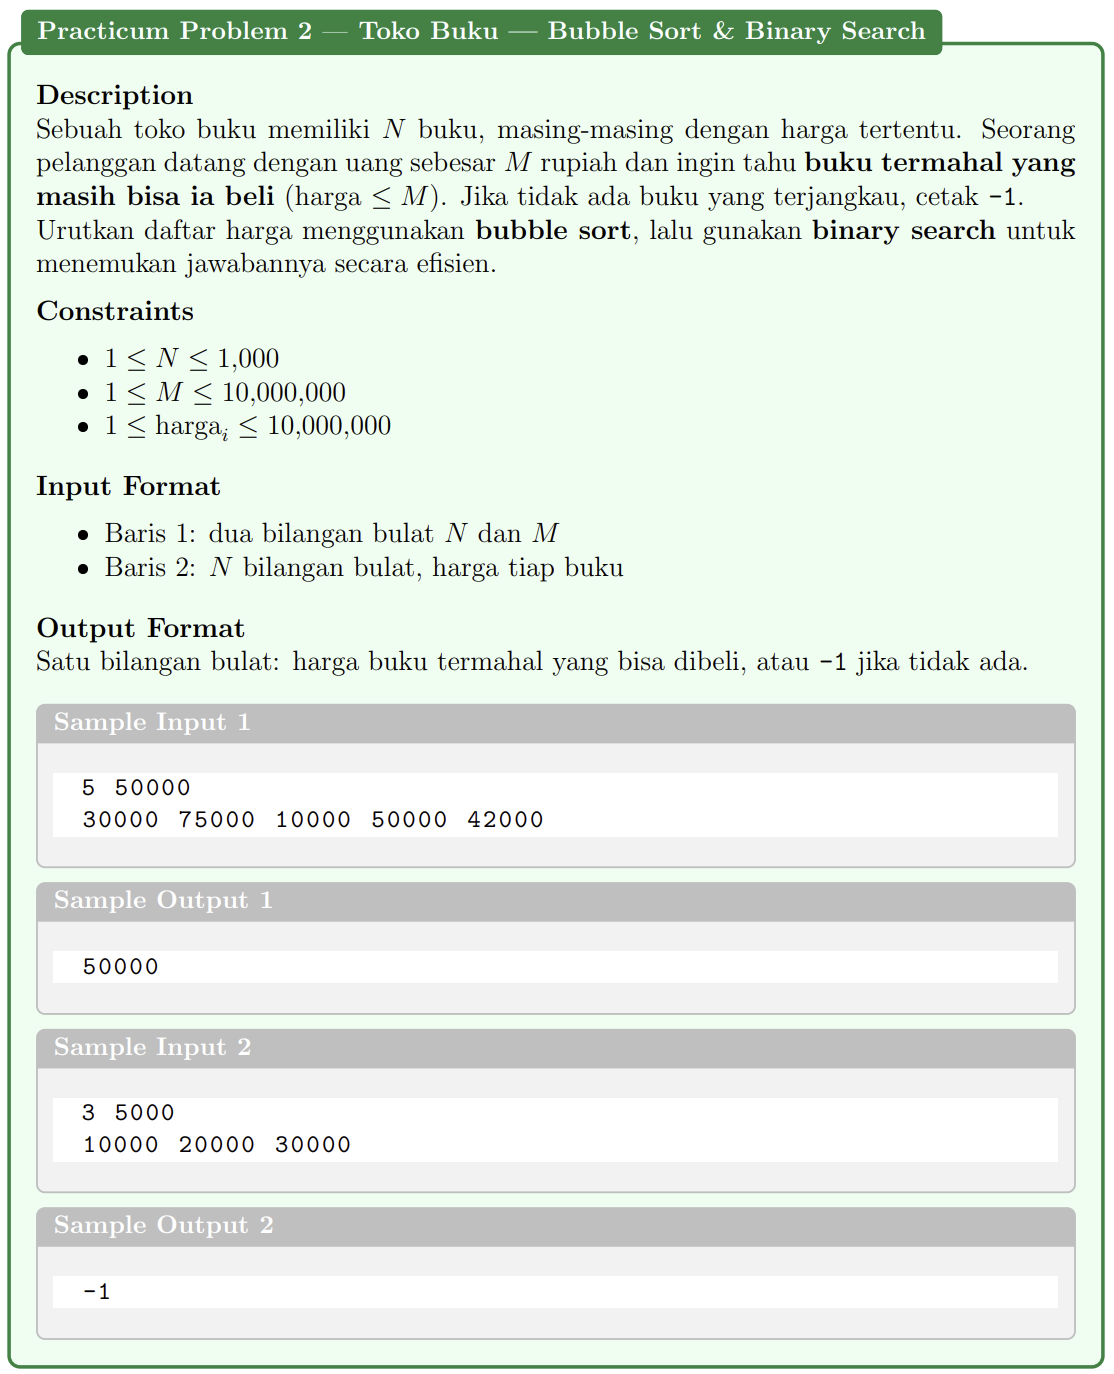

In [41]:
%%writefile daily210426_2.c
# include <stdio.h>

int main() {
  int jumlahBuku = 0;
  int uang = 0;
  
  int daftarHarga[1000] = {0};

  scanf("%d %d", &jumlahBuku, &uang);

  for (int i = 0; i < jumlahBuku; i++) {
    scanf("%d", &daftarHarga[i]);
  }

  // bubble sort: repeat swapping until no swapping is needed
  for (int i = 0; i < jumlahBuku; i++) {
    int swapped = 0;

    for (int j = 0; j < jumlahBuku; j++) {
      if (daftarHarga[i] < daftarHarga[i-1]) {
        int temp = daftarHarga[i];
        daftarHarga[i] = daftarHarga[i - 1];
        daftarHarga[i-1] = temp;
        swapped = 1;
      }
    }

    if (swapped == 0) {
      break;
    }
  }

  // binary search: when mid is lower than budget we remove all elements lower than mid + mid
                                                  & set mid as current highest price we can afford
  //                when mid is higher than budget we remove all elements higher than mid + mid
  int min = 0;
  int max = jumlahBuku - 1;
  int mid = 0;
  int hargaTermahal = -1;

  while (min <= max) {
    mid = (min + max)/2;

    if (daftarHarga[mid] < uang) {
      hargaTermahal = daftarHarga[mid];
      min = mid + 1;
    } else if (daftarHarga[mid] > uang) {
      max = mid - 1;
    } else if (daftarHarga[mid] == uang) {
      hargaTermahal = daftarHarga[mid];
      break;
    }
  }

  printf("%d\n", hargaTermahal);
  return 0;
}

Overwriting daily210426_2.c


In [42]:
!gcc daily210426_2.c -o daily210426_2 && echo 5 50000 30000 75000 10000 50000 42000 | daily210426_2.exe

daily210426_2.c: In function 'main':
daily210426_2.c:34:53: error: 'set' undeclared (first use in this function)
   34 |                                                   & set mid as current highest price we can afford
      |                                                     ^~~
daily210426_2.c:34:53: note: each undeclared identifier is reported only once for each function it appears in
daily210426_2.c:34:56: error: expected ';' before 'mid'
   34 |                                                   & set mid as current highest price we can afford
      |                                                        ^~~~
      |                                                        ;
daily210426_2.c:41:10: error: 'min' undeclared (first use in this function); did you mean 'mid'?
   41 |   while (min <= max) {
      |          ^~~
      |          mid


In [43]:
!gcc daily210426_2.c -o daily210426_2 && echo 3 5000 10000 20000 30000 | daily210426_2.exe

daily210426_2.c: In function 'main':
daily210426_2.c:34:53: error: 'set' undeclared (first use in this function)
   34 |                                                   & set mid as current highest price we can afford
      |                                                     ^~~
daily210426_2.c:34:53: note: each undeclared identifier is reported only once for each function it appears in
daily210426_2.c:34:56: error: expected ';' before 'mid'
   34 |                                                   & set mid as current highest price we can afford
      |                                                        ^~~~
      |                                                        ;
daily210426_2.c:41:10: error: 'min' undeclared (first use in this function); did you mean 'mid'?
   41 |   while (min <= max) {
      |          ^~~
      |          mid


### Question 3
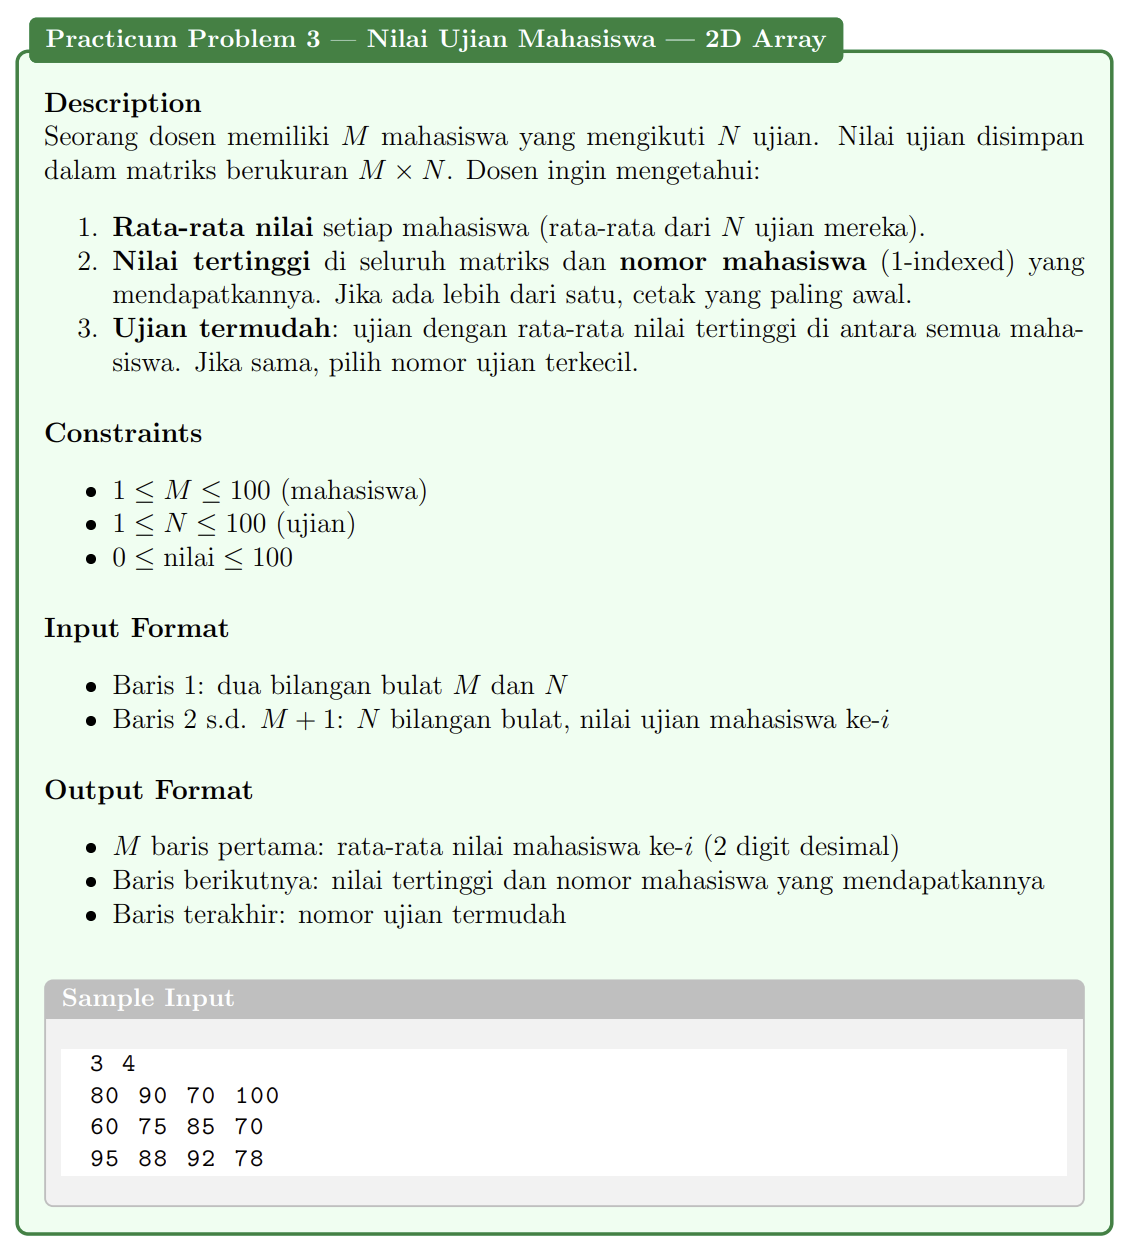
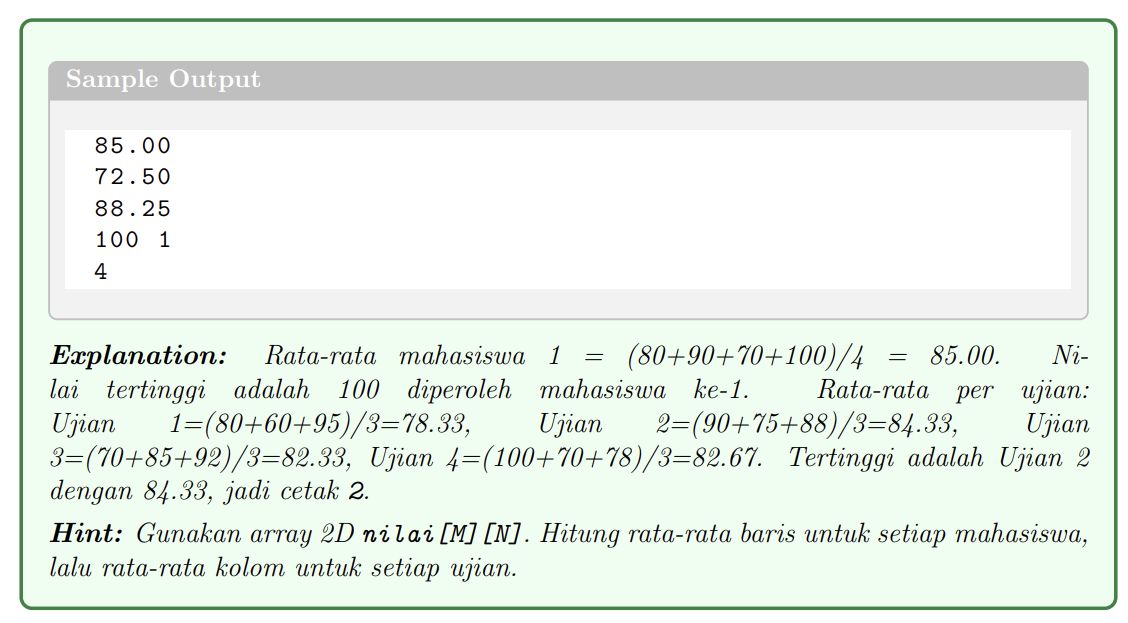

In [44]:
%%writefile daily210426_3.c
# include <stdio.h>

int main() {
  int jumlahMahasiswa = 0;
  int jumlahUjian = 0;

  int rekapanNilai[105][105] = {0};

  scanf("%d %d", &jumlahMahasiswa, &jumlahUjian);

  for (int i = 1; i <= jumlahMahasiswa; i++) {
    for (int j = 1; j <= jumlahUjian; j++) {
      scanf("%d", &rekapanNilai[i][j]);
    }
  }

  // Mencari rata-rata dari setiap mahasiswa
  int totalNilaiMahasiswa = 0;
  float rataRataMahasiswa = 0;

  // Mencari nilai maksimum
  int maxNilai = 0;
  int mahasiswaMax = 1;

  // Mencari rata-rata nilai per ujian
  int totalNilaiUjian = 0;
  int totalNilaiPerUjian[105] = {0};
  int maxTotalNilaiUjian = 0;
  int ujianTermudah = 1;

  for (int i = 1; i <= jumlahMahasiswa; i++) {
    for (int j = 1; j <= jumlahUjian; j++) {
      totalNilaiMahasiswa += rekapanNilai[i][j];

      if (rekapanNilai[i][j] > maxNilai) {
        maxNilai = rekapanNilai[i][j];
        mahasiswaMax = i;
      }

      totalNilaiPerUjian[j] += rekapanNilai[i][j];
    }
    rataRataMahasiswa = (totalNilaiMahasiswa * 1.0)/jumlahUjian;
    
    printf("%.2f\n", rataRataMahasiswa);
    rataRataMahasiswa = 0;
    totalNilaiMahasiswa = 0;
  }

  // Mencari yang paling mudah (total paling tinggi)
  for (int i = 1; i <= jumlahUjian; i++) {
    if (totalNilaiPerUjian[i] > maxTotalNilaiUjian) {
      maxTotalNilaiUjian = totalNilaiPerUjian[i];
      ujianTermudah = i;
    }
  }

  printf("%d %d\n", maxNilai, mahasiswaMax);
  printf("%d\n", ujianTermudah);

  return 0;
}

Overwriting daily210426_3.c


In [45]:
!gcc daily210426_3.c -o daily210426_3 && echo 3 4 80 90 70 100 60 75 85 70 95 88 92 78 | daily210426_3.exe

85.00
72.50
88.25
100 1
2
